# 🏥 Hospital Readmission Prediction
## Phase 2: Preprocessing & Feature Engineering

**Goal**: Transform raw data into a clean, model-ready feature matrix.  
**Input**: `diabetic_data.csv` (raw)  
**Output**: `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (saved to `/data/processed/`)

---
### Notebook Structure
1. Setup & Reload Data
2. Drop Irrelevant / High-Missing Columns
3. Handle Missing Values
4. Target Engineering
5. Feature Engineering
6. Encoding Categorical Variables
7. Train / Test Split
8. Handle Class Imbalance (SMOTE)
9. Save Processed Data
10. Summary

In [1]:
## 1. Setup & Reload Data
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from imblearn.over_sampling import SMOTE
from collections import Counter

os.makedirs('data/processed', exist_ok=True)
os.makedirs('plots', exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

print('✅ Libraries loaded')

✅ Libraries loaded


In [2]:
# ── Load Raw Data ─────────────────────────────────────────────────────────────
df = pd.read_csv("diabetic_data.csv")
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

df.replace('?', np.nan, inplace=True)

# Keep one encounter per patient (same as Phase 1)
df = df.sort_values('encounter_id').drop_duplicates(subset='patient_nbr', keep='first').copy()
df.reset_index(drop=True, inplace=True)

print(f'Shape after deduplication: {df.shape}')

Shape after deduplication: (71518, 51)


In [3]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

True
True
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmit_30']


In [4]:
## 2. Drop Irrelevant / High-Missing Columns
# ── Columns to Drop & Why ─────────────────────────────────────────────────────

# IDs — not predictive
id_cols = ['encounter_id', 'patient_nbr']

# High missing (>40% null after ? replacement)
high_missing_cols = ['weight', 'payer_code', 'medical_specialty']

# Low-variance or near-constant columns
low_variance_cols = ['examide', 'citoglipton']

# Raw target (we'll use the binary version)
raw_target_cols = ['readmitted']

cols_to_drop = id_cols + high_missing_cols + low_variance_cols

df.drop(columns=cols_to_drop, inplace=True)

print(f'Dropped {len(cols_to_drop)} columns: {cols_to_drop}')
print(f'Remaining columns: {df.shape[1]}')

Dropped 7 columns: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'medical_specialty', 'examide', 'citoglipton']
Remaining columns: 44


In [5]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

True
True
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmit_30']


In [6]:
## 3. Handle Missing Values
# ── Check Remaining Nulls ─────────────────────────────────────────────────────
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]
print('Remaining columns with nulls:')
print(remaining_nulls)
print()


Remaining columns with nulls:
race              1948
diag_1              11
diag_2             294
diag_3            1225
max_glu_serum    68062
A1Cresult        58532
dtype: int64



In [7]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

True
True
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmit_30']


In [8]:
# ── Imputation Strategy ───────────────────────────────────────────────────────

# race: fill with 'Unknown'
df['race'] = df['race'].fillna('Unknown')

# diag_1, diag_2, diag_3: fill with '999' (unknown/unspecified ICD code)
for col in ['diag_1', 'diag_2', 'diag_3']:
    df[col] = df[col].fillna('999')

# max_glu_serum: fill missing values
df['max_glu_serum'] = df['max_glu_serum'].fillna('Not Measured')

# A1Cresult: fill missing values
df['A1Cresult'] = df['A1Cresult'].fillna('Not Measured')

# gender: remove invalid/unknown values
df = df[df['gender'].isin(['Male', 'Female'])].copy()

# ── Verify No Remaining Nulls ────────────────────────────────────────────────
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

if len(remaining_nulls) > 0:
    print("⚠️ Columns still containing null values:")
    print(remaining_nulls)
else:
    print(f"✅ No remaining null values | Shape: {df.shape}")

✅ No remaining null values | Shape: (71515, 44)


In [9]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

True
True
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmit_30']


In [10]:
# Check remaining null values
remaining_nulls = df.isnull().sum()
remaining_nulls = remaining_nulls[remaining_nulls > 0]

print("Columns still containing null values:")
print(remaining_nulls)

Columns still containing null values:
Series([], dtype: int64)


In [11]:
## 4. Target Engineering
# ── Binary Target: readmitted within 30 days = 1 ─────────────────────────────
# (already present as 'readmit_30' if loaded from Phase 1, else create it)
## 4. Target Engineering

# Create binary target
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

# Save target
y = df['readmit_30'].copy()

# Remove target columns from features
df.drop(columns=['readmitted', 'readmit_30'], inplace=True)

print(f'Target distribution:\n{y.value_counts()}\n')
print(f'Positive class rate: {y.mean()*100:.1f}%')

Target distribution:
readmit_30
0    65222
1     6293
Name: count, dtype: int64

Positive class rate: 8.8%


In [12]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

False
False
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [13]:
print(df.shape)
print(y.shape)
print(y.value_counts())

(71515, 42)
(71515,)
readmit_30
0    65222
1     6293
Name: count, dtype: int64


In [14]:
print(df.columns.tolist())

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [15]:
## 5. Feature Engineering

# Creating new features that capture clinical patterns the raw columns miss.

# ── 5a. Total Prior Visits ────────────────────────────────────────────────────
# Patients with more prior visits are at higher readmission risk
df['total_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)
print('total_visits — sample stats:')
print(df['total_visits'].describe())

total_visits — sample stats:
count    71515.000000
mean         0.561463
std          1.431308
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         49.000000
Name: total_visits, dtype: float64


In [16]:
# ── 5b. Comorbidity Score ─────────────────────────────────────────────────────
# number_diagnoses captures how many conditions were coded during the visit
# We bin it into risk tiers (low / medium / high)
df['comorbidity_tier'] = pd.cut(
    df['number_diagnoses'],
    bins=[0, 3, 6, 100],
    labels=['low', 'medium', 'high']
)
print('Comorbidity tier distribution:')
print(df['comorbidity_tier'].value_counts())

Comorbidity tier distribution:
comorbidity_tier
high      46983
medium    21094
low        3438
Name: count, dtype: int64


In [17]:
# ── 5c. Medication Change Flag ────────────────────────────────────────────────
# 'change' column: 'Ch' = medication changed, 'No' = unchanged
df['med_change_flag'] = (df['change'] == 'Ch').astype(int)
print('Medication change flag distribution:')
print(df['med_change_flag'].value_counts())

Medication change flag distribution:
med_change_flag
0    39493
1    32022
Name: count, dtype: int64


In [18]:
# ── 5d. Insulin Adjustment Flag ───────────────────────────────────────────────
# 'insulin' column: Up/Down = adjusted, Steady/No = not adjusted
df['insulin_adjusted'] = df['insulin'].apply(
    lambda x: 1 if x in ['Up', 'Down'] else 0
)
print('Insulin adjusted distribution:')
print(df['insulin_adjusted'].value_counts())

Insulin adjusted distribution:
insulin_adjusted
0    57047
1    14468
Name: count, dtype: int64


In [19]:
# ── 5e. ICD-9 Diagnosis Category Mapping ─────────────────────────────────────
# Map raw ICD-9 codes → 10 clinical categories for diag_1, diag_2, diag_3

def map_icd9(code):
    try:
        code = str(code).upper().strip()
        if code.startswith('V') or code.startswith('E'):
            return 'external'
        c = float(code)
        if   390 <= c <= 459 or c == 785: return 'circulatory'
        elif 460 <= c <= 519 or c == 786: return 'respiratory'
        elif 520 <= c <= 579 or c == 787: return 'digestive'
        elif 250 <= c <= 250.93:          return 'diabetes'
        elif 800 <= c <= 999:             return 'injury'
        elif 710 <= c <= 739:             return 'musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'genitourinary'
        elif 140 <= c <= 239:             return 'neoplasms'
        elif 290 <= c <= 319:             return 'mental'
        else:                             return 'other'
    except:
        return 'other'

for d_col in ['diag_1', 'diag_2', 'diag_3']:
    df[f'{d_col}_cat'] = df[d_col].apply(map_icd9)

# Drop the raw ICD code columns
df.drop(columns=['diag_1', 'diag_2', 'diag_3'], inplace=True)

print('diag_1_cat distribution:')
print(df['diag_1_cat'].value_counts())

diag_1_cat distribution:
diag_1_cat
circulatory        21893
other               9871
respiratory         9776
digestive           6570
diabetes            5805
injury              4788
musculoskeletal     4080
genitourinary       3514
neoplasms           2742
mental              1548
external             928
Name: count, dtype: int64


In [20]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

False
False
['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'total_visits', 'comorbidity_tier', 'med_change_flag', 'insulin_adjusted', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']


In [21]:
# ── 5f. Age Group → Numeric Midpoint ─────────────────────────────────────────
# Convert '[30-40)' style brackets to numeric midpoint (35)
age_map = {
    '[0-10)': 5,   '[10-20)': 15,  '[20-30)': 25,  '[30-40)': 35,
    '[40-50)': 45, '[50-60)': 55,  '[60-70)': 65,  '[70-80)': 75,
    '[80-90)': 85, '[90-100)': 95
}
df['age_numeric'] = df['age'].map(age_map)
df.drop(columns=['age'], inplace=True)

print('age_numeric — sample stats:')
print(df['age_numeric'].describe())

age_numeric — sample stats:
count    71515.000000
mean        65.651612
std         15.978333
min          5.000000
25%         55.000000
50%         65.000000
75%         75.000000
max         95.000000
Name: age_numeric, dtype: float64


In [22]:
# ── Engineered Features Summary ───────────────────────────────────────────────
new_features = ['total_visits', 'comorbidity_tier', 'med_change_flag',
                'insulin_adjusted', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'age_numeric']
print(f'✅ {len(new_features)} new features engineered: {new_features}')
print(f'\nCurrent shape: {df.shape}')

✅ 8 new features engineered: ['total_visits', 'comorbidity_tier', 'med_change_flag', 'insulin_adjusted', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'age_numeric']

Current shape: (71515, 46)


In [23]:
print("readmitted" in df.columns)
print("readmit_30" in df.columns)

print(df.columns.tolist())

False
False
['race', 'gender', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'total_visits', 'comorbidity_tier', 'med_change_flag', 'insulin_adjusted', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat', 'age_numeric']


In [24]:
df.head()

,race,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,change,diabetesMed,total_visits,comorbidity_tier,med_change_flag,insulin_adjusted,diag_1_cat,diag_2_cat,diag_3_cat,age_numeric
0,Caucasian,Female,2,1,4,13,68,2,28,0,...,Ch,Yes,0,high,1,0,circulatory,circulatory,other,85
1,Caucasian,Female,3,3,4,12,33,3,18,0,...,Ch,Yes,0,high,1,0,circulatory,neoplasms,respiratory,95
2,Caucasian,Male,1,1,7,1,51,0,8,0,...,Ch,Yes,0,medium,1,0,neoplasms,neoplasms,diabetes,45
3,AfricanAmerican,Female,1,1,7,9,47,2,17,0,...,No,Yes,0,high,0,0,diabetes,circulatory,injury,45
4,Caucasian,Male,2,1,2,3,31,6,16,0,...,No,Yes,0,high,0,0,circulatory,circulatory,diabetes,55


In [25]:
## 6. Encoding Categorical Variables
# ── Identify Categorical Columns ───────────────────────────────────────────────
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'\nNumeric columns ({len(num_cols)}): {num_cols}')

Categorical columns (31): ['race', 'gender', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'comorbidity_tier', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

Numeric columns (15): ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'total_visits', 'med_change_flag', 'insulin_adjusted', 'age_numeric']


In [26]:
# ── Binary Encoding (2-class columns) ────────────────────────────────────────
binary_map = {
    'gender'       : {'Male': 1, 'Female': 0},
    'diabetesMed'  : {'Yes': 1, 'No': 0},
}
for col, mapping in binary_map.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f'  ✅ Binary encoded: {col}')

  ✅ Binary encoded: gender
  ✅ Binary encoded: diabetesMed


In [27]:
# ── Ordinal Encoding (ordered categories) ────────────────────────────────────

# comorbidity_tier: low < medium < high
comorbidity_order = [['low', 'medium', 'high']]
oe = OrdinalEncoder(categories=comorbidity_order)
df['comorbidity_tier'] = oe.fit_transform(df[['comorbidity_tier']])
print('✅ Ordinal encoded: comorbidity_tier')

# Medication dosage columns (No < Steady < Down < Up)
med_dose_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone',
                 'rosiglitazone', 'acarbose', 'insulin',
                 'glyburide-metformin', 'tolbutamide', 'miglitol']

dose_order = [['No', 'Steady', 'Down', 'Up']]
for col in med_dose_cols:
    if col in df.columns:
        oe_med = OrdinalEncoder(categories=dose_order, handle_unknown='use_encoded_value', unknown_value=-1)
        df[col] = oe_med.fit_transform(df[[col]])
        
print(f'✅ Ordinal encoded {len(med_dose_cols)} medication dosage columns')

✅ Ordinal encoded: comorbidity_tier
✅ Ordinal encoded 14 medication dosage columns


In [28]:
# ── One-Hot Encoding (nominal categories) ────────────────────────────────────
remaining_cats = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f'Columns to one-hot encode: {remaining_cats}')

df = pd.get_dummies(df, columns=remaining_cats, drop_first=True, dtype=int)

print(f'\n✅ One-hot encoding complete')
print(f'Final feature matrix shape: {df.shape}')

Columns to one-hot encode: ['race', 'max_glu_serum', 'A1Cresult', 'acetohexamide', 'troglitazone', 'tolazamide', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diag_1_cat', 'diag_2_cat', 'diag_3_cat']

✅ One-hot encoding complete
Final feature matrix shape: (71515, 80)


In [29]:
# ── Final Column Types Check ───────────────────────────────────────────────────
non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f'⚠️  Non-numeric columns remaining: {non_numeric}')
else:
    print('✅ All columns are numeric — ready for modeling')

print(f'\nFinal DataFrame shape: {df.shape}')
df.head(3)

✅ All columns are numeric — ready for modeling

Final DataFrame shape: (71515, 80)


,gender,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,...,diag_3_cat_diabetes,diag_3_cat_digestive,diag_3_cat_external,diag_3_cat_genitourinary,diag_3_cat_injury,diag_3_cat_mental,diag_3_cat_musculoskeletal,diag_3_cat_neoplasms,diag_3_cat_other,diag_3_cat_respiratory
0,0,2,1,4,13,68,2,28,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,3,3,4,12,33,3,18,0,0,...,0,0,0,0,0,0,0,0,0,1
2,1,1,1,7,1,51,0,8,0,0,...,1,0,0,0,0,0,0,0,0,0


In [30]:
## 7. Train / Test Split
# ── Stratified 80/20 Split ────────────────────────────────────────────────────
# Stratified = preserves class ratio in both train and test sets

X = df.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train set: {X_train.shape[0]:,} rows')
print(f'Test set : {X_test.shape[0]:,} rows')
print(f'\nClass ratio in train: {y_train.mean()*100:.1f}% positive')
print(f'Class ratio in test : {y_test.mean()*100:.1f}% positive')
print('✅ Stratification maintained class balance')

Train set: 57,212 rows
Test set : 14,303 rows

Class ratio in train: 8.8% positive
Class ratio in test : 8.8% positive
✅ Stratification maintained class balance



## 8. Handle Class Imbalance — SMOTE

**Why SMOTE?** The dataset is imbalanced (~11% positive class). Without correction, models learn to predict "not readmitted" for everything and still get 89% accuracy — useless clinically.  

**SMOTE** (Synthetic Minority Over-sampling Technique) generates synthetic samples of the minority class in feature space — better than simple oversampling.

> ⚠️ **Important**: Apply SMOTE **only on training data**, never on test data. The test set must reflect real-world distribution.

In [31]:
# ── Apply SMOTE to Training Set Only ─────────────────────────────────────────
print(f'Before SMOTE — Train class distribution: {Counter(y_train)}')

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f'After SMOTE  — Train class distribution: {Counter(y_train_resampled)}')
print(f'\nTrain set grew from {len(X_train):,} → {len(X_train_resampled):,} rows')
print(f'Test set stays at {len(X_test):,} rows (untouched)')

Before SMOTE — Train class distribution: Counter({0: 52178, 1: 5034})
After SMOTE  — Train class distribution: Counter({1: 52178, 0: 52178})

Train set grew from 57,212 → 104,356 rows
Test set stays at 14,303 rows (untouched)


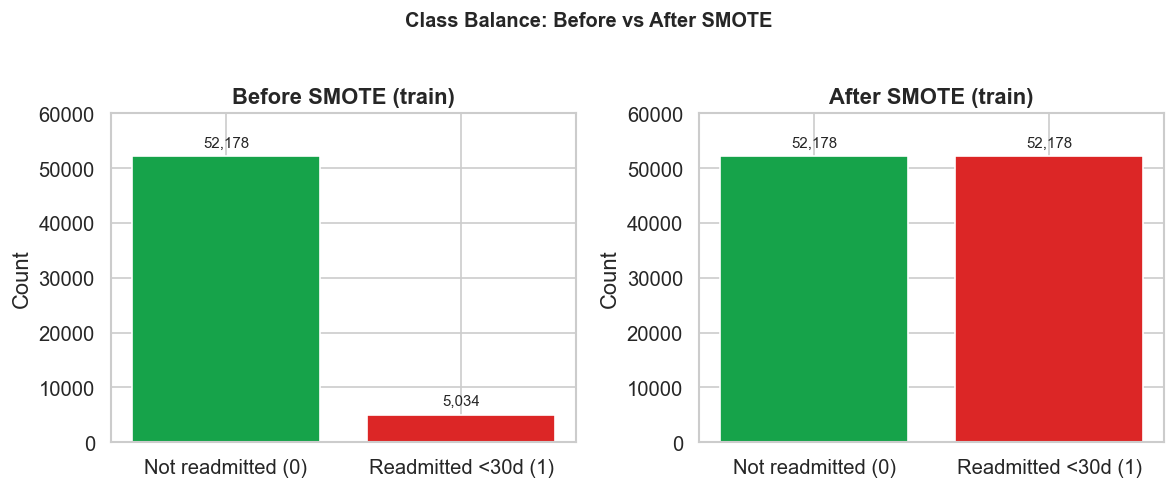

In [32]:
# ── Visualise Class Balance Before vs After ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, y_data, title in zip(
    axes,
    [y_train, y_train_resampled],
    ['Before SMOTE (train)', 'After SMOTE (train)']
):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Not readmitted (0)', 'Readmitted <30d (1)'],
                  counts.values,
                  color=['#16A34A', '#DC2626'], edgecolor='white')
    ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_ylim(0, counts.max() * 1.15)

plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/12_smote_balance.png', bbox_inches='tight')
plt.show()

In [33]:
## 9. Save Processed Data
# ── Save to /data/processed/ ──────────────────────────────────────────────────
# Original split (for test evaluation and non-SMOTE models)
X_train.to_csv('data/processed/X_train.csv', index=False)
X_test.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

# SMOTE-resampled training data
pd.DataFrame(X_train_resampled, columns=X_train.columns).to_csv(
    'data/processed/X_train_smote.csv', index=False)
pd.Series(y_train_resampled, name='readmit_30').to_csv(
    'data/processed/y_train_smote.csv', index=False)

# Save feature names for use in Phase 3 & Phase 5 (Streamlit)
feature_names = list(X_train.columns)
pd.Series(feature_names).to_csv('data/processed/feature_names.csv', index=False, header=False)

print('✅ All processed files saved to data/processed/')
print()
for fname in os.listdir('data/processed'):
    path = f'data/processed/{fname}'
    size = os.path.getsize(path) / 1024
    print(f'  {fname:35s} {size:.1f} KB')

✅ All processed files saved to data/processed/

  feature_names.csv                   1.5 KB
  X_test.csv                          2710.3 KB
  X_train.csv                         10837.2 KB
  X_train_smote.csv                   21159.0 KB
  y_test.csv                          41.9 KB
  y_train.csv                         167.6 KB
  y_train_smote.csv                   305.7 KB


In [35]:
## 10. Phase 2 Summary
n_features = X_train.shape[1]
n_train    = len(X_train_resampled)
n_test     = len(X_test)

summary = f"""
╔══════════════════════════════════════════════════════════╗
║          PHASE 2 SUMMARY — PREPROCESSING COMPLETE       ║
╠══════════════════════════════════════════════════════════╣
║ Cleaning                                                 ║
║   • Replaced ? → NaN                                    ║
║   • Dropped: weight, payer_code, medical_specialty,     ║
║     examide, citoglipton (high missing / near-constant) ║
║   • Imputed race → 'Unknown', diag → '999'              ║
╠══════════════════════════════════════════════════════════╣
║ Feature Engineering                                      ║
║   • total_visits (outpatient + emergency + inpatient)   ║
║   • comorbidity_tier (low / medium / high)              ║
║   • med_change_flag (binary)                            ║
║   • insulin_adjusted (binary)                           ║
║   • diag_1/2/3_cat (ICD-9 → 10 clinical categories)    ║
║   • age_numeric (bracket midpoints)                     ║
╠══════════════════════════════════════════════════════════╣
║ Encoding                                                 ║
║   • Binary: gender, diabetesMed                         ║
║   • Ordinal: comorbidity_tier, 14 medication cols       ║
║   • One-hot: race, diag_*_cat, admission cols           ║
╠══════════════════════════════════════════════════════════╣
║ Final Dataset                                            ║
║   Total features : {n_features}                          ║
║   Train (SMOTE)  : {n_train:,} rows (balanced 50/50)      ║
║   Test           : {n_test:,} rows (real-world dist.)    ║
╠══════════════════════════════════════════════════════════╣
║ Next → Phase 3: Modeling                                 ║
║   1. Logistic Regression (baseline)                     ║
║   2. Random Forest                                      ║
║   3. XGBoost / LightGBM                                 ║
║   4. Compare: ROC-AUC, F1, Precision-Recall             ║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════╗
║          PHASE 2 SUMMARY — PREPROCESSING COMPLETE       ║
╠══════════════════════════════════════════════════════════╣
║ Cleaning                                                 ║
║   • Replaced ? → NaN                                    ║
║   • Dropped: weight, payer_code, medical_specialty,     ║
║     examide, citoglipton (high missing / near-constant) ║
║   • Imputed race → 'Unknown', diag → '999'              ║
╠══════════════════════════════════════════════════════════╣
║ Feature Engineering                                      ║
║   • total_visits (outpatient + emergency + inpatient)   ║
║   • comorbidity_tier (low / medium / high)              ║
║   • med_change_flag (binary)                            ║
║   • insulin_adjusted (binary)                           ║
║   • diag_1/2/3_cat (ICD-9 → 10 clinical categories)    ║
║   • age_numeric (bracket midpoints)                     ║
╠══════════════════════════════════